<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/El_Algoritmo_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Backpropagation: Cómo Aprenden las Redes Neuronales**
## **Implementación manual de MLP con NumPy: del XOR a la práctica con scikit-learn**

## Índice

1. **Introducción: El Problema XOR**
   * ¿Qué es XOR y por qué es importante?
   * Visualización del problema: puntos no separables linealmente
   * El límite del Perceptrón Simple

2. **Anatomía de una Red Neuronal Multicapa (MLP)**
   * Estructura: Entrada (2) → Oculta (4) → Salida (1)
   * Pesos, sesgos y conexiones
   * La función de activación Sigmoide: añadiendo no-linealidad

3. **Forward Propagation: El Camino de Ida**
   * Flujo de información a través de las capas
   * Cálculo de activaciones capa por capa
   * Obteniendo la predicción final

4. **La Función de Coste (Loss Function)**
   * ¿Qué estamos tratando de minimizar?
   * Error Cuadrático Medio (MSE)
   * Interpretación geométrica del error

5. **Backpropagation: El Motor del Aprendizaje**
   * La Regla de la Cadena aplicada a redes neuronales
   * Calculando gradientes: ¿cuánto contribuye cada peso al error?
   * Propagando el error hacia atrás

6. **Descenso del Gradiente**
   * Actualizando pesos en la dirección correcta
   * El Learning Rate: equilibrio entre velocidad y estabilidad
   * Iteración tras iteración: el proceso de entrenamiento

7. **Implementación desde Cero con NumPy**
   * Inicialización de pesos y sesgos
   * Código completo del algoritmo
   * Entrenamiento: observando la convergencia
   * Visualización de la curva de pérdida

8. **Validación: ¿Aprendió correctamente?**
   * Evaluación de las predicciones
   * Visualización del espacio de decisión aprendido

9. **Solución Profesional con Scikit-Learn**
   * MLPClassifier: la misma red en pocas líneas
   * Comparación de resultados
   * Cuándo usar implementación manual vs. librería

10. **Conclusiones y Próximos Pasos**
    * Recapitulación: el poder de las capas ocultas
    * Limitaciones de las MLP clásicas
    * Camino hacia redes más profundas (Deep Learning)

---

# 1. Introducción: El Problema XOR

## ¿Qué es XOR y por qué es importante?

XOR (eXclusive OR, "O exclusivo" en español) es una operación lógica fundamental que devuelve `True` (1) únicamente cuando sus dos entradas son **diferentes**, y `False` (0) cuando son iguales. Es decir, la salida es verdadera si una entrada u otra es verdadera, pero **no ambas a la vez**.

Veamos su tabla de verdad:

| x₁ | x₂ | XOR (salida) |
|----|----|--------------|
| 0  | 0  | 0            |
| 0  | 1  | 1            |
| 1  | 0  | 1            |
| 1  | 1  | 0            |

A simple vista, XOR parece un problema trivial. Sin embargo, este sencillo operador lógico tiene una **importancia histórica crucial** en el desarrollo de las redes neuronales artificiales.

En 1969, Marvin Minsky y Seymour Papert publicaron el libro *"Perceptrons"*, donde demostraron matemáticamente que **un perceptrón simple (una única neurona) no puede resolver el problema XOR**. Esta demostración fue tan influyente que provocó lo que se conoce como el "invierno de la IA": un período de más de una década donde la financiación y el interés en redes neuronales prácticamente desaparecieron.

La solución a este problema llegaría años después con las **redes neuronales multicapa** y el algoritmo de **backpropagation**, que es precisamente lo que aprenderemos en este artículo.

## Visualización: dos fronteras lineales son necesarias

Para entender por qué XOR es tan problemático, visualicemos los cuatro puntos de datos en un espacio 2D:

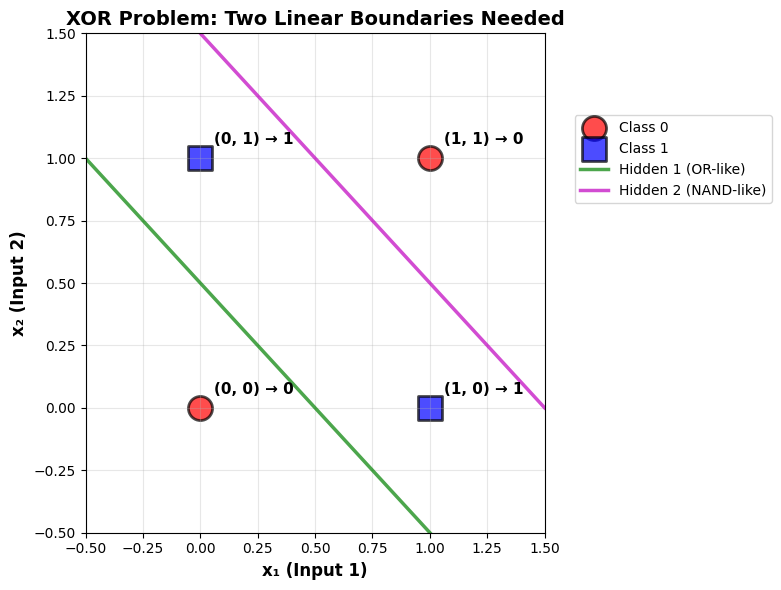

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 0])

# Create visualization
plt.figure(figsize=(8, 6))

# Plot points with different colors for each class
colors = ['red' if label == 0 else 'blue' for label in y]
markers = ['o' if label == 0 else 's' for label in y]

for i, (point, color, marker) in enumerate(zip(X, colors, markers)):
    plt.scatter(point[0], point[1], c=color, marker=marker, s=300,
                edgecolors='black', linewidths=2, alpha=0.7,
                label=f'Class {y[i]}' if i < 2 else '')

# Add labels to each point
for i, point in enumerate(X):
    plt.annotate(f'({point[0]}, {point[1]}) → {y[i]}',
                 xy=point, xytext=(10, 10),
                 textcoords='offset points', fontsize=11, fontweight='bold')

# Draw two linear boundaries (what hidden neurons learn)
x_line = np.linspace(-0.5, 1.5, 100)

# First boundary: OR-like (separates (0,0) from the rest)
y_line1 = -x_line + 0.5
plt.plot(x_line, y_line1, 'g-', linewidth=2.5, alpha=0.7, label='Hidden 1 (OR-like)')

# Second boundary: NAND-like (separates (1,1) from the rest)
y_line2 = -x_line + 1.5
plt.plot(x_line, y_line2, 'm-', linewidth=2.5, alpha=0.7, label='Hidden 2 (NAND-like)')

plt.xlabel('x₁ (Input 1)', fontsize=12, fontweight='bold')
plt.ylabel('x₂ (Input 2)', fontsize=12, fontweight='bold')
plt.title('XOR Problem: Two Linear Boundaries Needed', fontsize=14, fontweight='bold')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 0.85), fontsize=10)
plt.tight_layout()
plt.show()

En la gráfica podemos observar algo fundamental: aunque **una sola línea recta no puede separar** los puntos rojos (clase 0) de los azules (clase 1), **dos líneas rectas sí pueden resolver el problema**:

- **La línea verde (Hidden 1)**: Actúa como un operador OR, separando el punto (0,0) del resto.
- **La línea magenta (Hidden 2)**: Actúa como un operador NAND (NOT AND), separando el punto (1,1) del resto.

Cuando **combinamos** ambas fronteras lineales en una capa oculta, la red puede aprender una representación donde XOR se vuelve separable. Este es el insight clave: la capa oculta transforma el espacio de entrada en un nuevo espacio donde el problema ya no es linealmente inseparable.

Cada neurona de la capa oculta aprende una de estas fronteras lineales, y la neurona de salida aprende a combinar sus respuestas para producir la clasificación correcta. En lugar de intentar resolver XOR directamente con una línea, la red lo descompone en subproblemas más simples.

## El límite del Perceptrón Simple y la necesidad de capas ocultas

En nuestro artículo anterior sobre el perceptrón, vimos cómo una única neurona puede resolver perfectamente los problemas AND y OR. La razón es simple: estos problemas son **linealmente separables**. Un perceptrón aprende una función de la forma:

**salida = sigmoide(w₁·x₁ + w₂·x₂ + b)**

Esta ecuación define una **línea recta** (o más precisamente, un hiperplano en dimensiones superiores) que divide el espacio en dos regiones. Como acabamos de ver en la visualización, XOR necesita **al menos dos líneas** para ser resuelto correctamente.

En el artículo previo también construimos manualmente una red neuronal con arquitectura **2:2:1** (2 entradas → 2 neuronas ocultas → 1 salida) donde *hardcodeamos* los pesos y sesgos para resolver XOR. Esa solución funcionaba porque manualmente configuramos dos neuronas: una para cada frontera de decisión. Sin embargo, tenía **dos limitaciones críticas**:

1. **No es una solución aprendida:** Tuvimos que calcular manualmente los valores exactos de los pesos porque conocíamos de antemano la estructura lógica del problema (XOR se puede descomponer en operaciones OR y NAND).

2. **Inestabilidad durante el entrenamiento:** Con solo 2 neuronas ocultas, el espacio de soluciones es extremadamente estrecho. Si intentáramos entrenar esa red desde pesos aleatorios usando backpropagation, el algoritmo tendría **grandes dificultades para converger** hacia una solución válida. El paisaje de error es complejo y tiene muchos mínimos locales problemáticos.

**¿Cuál es la solución?** Usar una arquitectura con **más neuronas en la capa oculta**. En este artículo trabajaremos con una arquitectura **2:4:1** (2 entradas → **4 neuronas ocultas** → 1 salida).

¿Por qué 4 neuronas cuando solo necesitamos 2 fronteras? Esta configuración proporciona:
- **Mayor flexibilidad representacional:** La red puede aprender múltiples combinaciones de características y no está restringida a una solución específica.
- **Espacio de optimización más suave:** El algoritmo de descenso del gradiente encuentra caminos más estables hacia la solución. Las neuronas "extra" actúan como redundancia que facilita el aprendizaje.
- **Robustez durante el entrenamiento:** Si una neurona se queda atascada en un mal estado durante las primeras iteraciones, las otras pueden compensar y guiar el aprendizaje.

Con esta arquitectura ampliada y el algoritmo de **backpropagation**, nuestra red será capaz de **aprender completamente por sí misma** a resolver XOR, sin que tengamos que especificar manualmente ni un solo peso. El modelo descubrirá automáticamente las fronteras de decisión necesarias (probablemente aprendiendo algo similar a las líneas verde y magenta que vimos, más otras transformaciones auxiliares).

En las próximas secciones diseccionaremos exactamente cómo funciona este proceso de aprendizaje automático.

---